In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven

In [3]:
design = designs.DesignPlanar()
design._chips['main']['size']['size_x'] = '9mm'
design._chips['main']['size']['size_y'] = '9mm'
gui = MetalGUI(design)
design.overwrite_enabled = True

09:36PM 17s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: Populating font family aliases took 119 ms. Replace uses of missing font family "Courier" with one that exists to avoid this cost. 



2025-07-28 21:36:17.988 python[33167:252356237] +[IMKClient subclass]: chose IMKClient_Modern
2025-07-28 21:36:17.988 python[33167:252356237] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [4]:
# Select a QComponent to create (The QComponent is a python class named `TransmonPocket`)
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

In [5]:
# Create a new qcomponent object with name 'Q1' 
#q1 = TransmonPocket(design, 'Q1')
#gui.rebuild()  # rebuild the design and plot 

In [ ]:

from qiskit_metal import draw, Dict
from qiskit_metal.qlibrary.core import QComponent
import gdspy

class MyQComponent(QComponent):
    """Demonstration1 - Straight segment with variable width/length"""

    ### def __init__() <- comes from QComponent
    ###   Initiaizes base variables such as self.id, self.name and self.options
    ###   Also launches the first execution of make()

    ### def rebuild() <- comes from QComponent
    ###   Clear output from previous runs of make() (geom/pin/net) and re-runs it

    def make(self):
        lib = gdspy.GdsLibrary()
        filename = '../PHIDL-based/output/qiskit-metal/TcSampleDesign.gds'
        scale = 1e-3
        #print( gdspy.get_gds_units(filename) )
        #print( design.get_units())
        lib.read_gds(filename, 'import')
        print(lib)
        cell = lib.top_level()[0]

        polygon_list = []        
        polygon_pocket_list = []                
        for polygon in cell.polygons:
            for poly_points, layer in zip(polygon.polygons, polygon.layers):
                poly = draw.Polygon(poly_points * scale)
                if layer == 1:
                    self.add_qgeometry('poly', dict(poly=poly), subtract = True, layer=1)
                    polygon_pocket_list.extend(poly_points * scale)
                else:
                    self.add_qgeometry('poly', dict(poly=poly), subtract = False, layer=1)    
                    polygon_list.extend(poly_points * scale)                

        # y座標で降順にソート (一番上の2点が先頭)
        sorted_by_y_desc = sorted(polygon_list, key=lambda p: p[1], reverse=True)
        sorted_by_y_desc_pocket = sorted(polygon_pocket_list, key=lambda p: p[1], reverse=True)
        # 一番上の2頂点
        top_2 = sorted_by_y_desc[:2]
        top_pocket_2 = sorted_by_y_desc_pocket[:2]        

        # y座標で昇順にソート (一番下の2点が先頭)
        sorted_by_y_asc = sorted(polygon_list, key=lambda p: p[1])
        sorted_by_y_asc_pocket = sorted(polygon_pocket_list, key=lambda p: p[1])

        # 一番下の2頂点
        bottom_2 = sorted_by_y_asc[:2]
        bottom_pocket_2 = sorted_by_y_asc_pocket[:2]        

        width = top_2[0][0] - top_2[1][0]
        gap = top_pocket_2[0][1] - top_2[0][1]

        input_pin_line = draw.LineString(top_pocket_2)
        output_pin_line = draw.LineString(bottom_pocket_2)        
        self.add_pin('in', input_pin_line.coords, width, gap=gap)
        self.add_pin('out', output_pin_line.coords, width, gap=gap)        

In [16]:
test = MyQComponent(design, 'test')

# Driven Lauchpad 1
x = '-1.5mm'
y = '2.0mm'
launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='360', lead_length='30um')
LP1 = LaunchpadWirebondDriven(design, 'LP1', options = launch_options)
design.components.LP1.pins.keys()

gui.rebuild()  # rebuild the design and plot

GdsLibrary (toplevel)
[array([-0.24,  1.84]), array([-0.56,  1.84])]
[array([-0.56, -1.84]), array([-0.24, -1.84])]
0.32000000000000006
0.17000000000000015
GdsLibrary (toplevel)
[array([-0.24,  1.84]), array([-0.56,  1.84])]
[array([-0.56, -1.84]), array([-0.24, -1.84])]
0.32000000000000006
0.17000000000000015


GdsLibrary (toplevel)
[array([-0.24,  1.84]), array([-0.56,  1.84])]
[array([-0.56, -1.84]), array([-0.24, -1.84])]
0.32000000000000006
0.17000000000000015


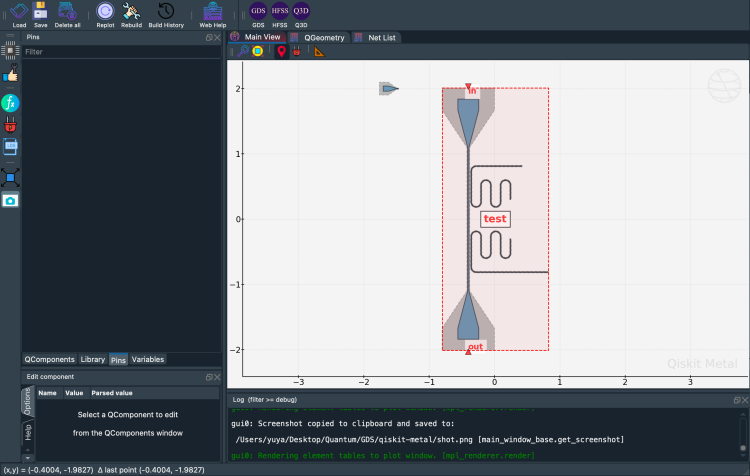

In [18]:
component = "test"
gui.rebuild()
#gui.autoscale()
#gui.edit_component(component)
gui.zoom_on_components([component])
gui.highlight_components([component])
gui.screenshot()